In [2]:
import numpy as np
import torch
import torch.nn as nn
from torchdiffeq import odeint
from torchcfm.conditional_flow_matching import ConditionalFlowMatcher
from sklearn.preprocessing import StandardScaler
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from TrajectoryNet import dataset
import pickle
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
eb_data = dataset.EBData("pcs", max_dim=50)
data = eb_data.data
labels = eb_data.get_times()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
timepoints = np.unique(labels)

def get_data_by_timepoint(data_scaled, labels):
    data_by_t = {}
    for t in np.unique(labels):
        mask = labels == t
        data_by_t[t] = torch.FloatTensor(data_scaled[mask]).to(device)
    return data_by_t

data_by_t = get_data_by_timepoint(data_scaled, labels)

obs_by_t_pca = {}
for t in timepoints:
    mask = labels == t
    obs_by_t_pca[t] = data[mask]

print(f"Data loaded: {data.shape}")

Data loaded: (16819, 50)


In [4]:
class ODEFunc(nn.Module):
    def __init__(self, dim, hidden_dim=64):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, dim)
        )
    def forward(self, t, z):
        t_vec = t.expand(z.shape[0], 1)
        inp = torch.cat([z, t_vec], dim=1)
        return self.net(inp)

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=128, dropout=0.1):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout)
        )
        self.fc_mu  = nn.Linear(hidden_dim, latent_dim)
        self.fc_var = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim)
        )
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_var(h)
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)
    def decode(self, z):
        return self.decoder(z)
    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var

class VectorField(nn.Module):
    def __init__(self, dim, hidden_dim=64):
        super(VectorField, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, dim)
        )
    def forward(self, t, x):
        if t.dim() == 0:
            t_vec = t.expand(x.shape[0], 1)
        else:
            t_vec = t.view(-1, 1).expand(x.shape[0], 1)
        return self.net(torch.cat([x, t_vec], dim=1))

print("All architectures defined.")

All architectures defined.


In [5]:
# Neural ODE on 50D PCA
model_node = ODEFunc(dim=50).to(device)
model_node.load_state_dict(torch.load('../models/node_50d.pt'))
model_node.eval()

# Sequential VAE + ODE
vae_seq = VAE(50, 10, 128, 0.1).to(device)
vae_seq.load_state_dict(torch.load('../models/vae.pt'))
vae_seq.eval()

model_vae_ode = ODEFunc(dim=6).to(device)
model_vae_ode.load_state_dict(torch.load('../models/node_vae.pt'))
model_vae_ode.eval()

with open('../models/scaler.pkl', 'rb') as f:
    scaler_vae = pickle.load(f)
active_dims = np.load('../data/active_dims.npy')
Z_latent = np.load('../data/Z_latent_active.npy')
labels_vae = np.load('../data/labels.npy')

def get_data_by_timepoint_raw(data, labels):
    data_by_t = {}
    for t in np.unique(labels):
        mask = labels == t
        data_by_t[t] = torch.FloatTensor(data[mask]).to(device)
    return data_by_t

data_by_t_vae = get_data_by_timepoint_raw(Z_latent, labels_vae)

# Joint VAE + ODE
joint_vae = VAE(50, 10, 128, 0.1).to(device)
joint_vae.load_state_dict(torch.load('../models/joint_vae.pt'))
joint_vae.eval()

joint_ode = ODEFunc(dim=10).to(device)
joint_ode.load_state_dict(torch.load('../models/joint_ode.pt'))
joint_ode.eval()

with open('../models/joint_scaler.pkl', 'rb') as f:
    scaler_joint = pickle.load(f)

# Flow Matching
model_fm = VectorField(dim=50).to(device)
model_fm.load_state_dict(torch.load('../models/flow_matching.pt'))
model_fm.eval()

print("All models loaded.")

All models loaded.


In [6]:
def evaluate_wasserstein(pred_by_t, obs_by_t_pca, timepoints, 
                          n_eval=500, n_runs=5):
    """
    Run Wasserstein evaluation n_runs times and return mean and std.
    pred_by_t: dict mapping timepoint -> numpy array of predicted cells in 50D PCA space
    """
    all_avgs = []
    for _ in range(n_runs):
        w_dists = []
        for t in timepoints[1:-1]:
            pred = pred_by_t[t]
            obs  = obs_by_t_pca[t]
            idx_obs = np.random.choice(len(obs), size=min(n_eval, len(pred)), replace=False)
            obs_s   = obs[idx_obs]
            pred_s  = pred[:len(obs_s)]
            w = np.mean([wasserstein_distance(pred_s[:, d], obs_s[:, d]) for d in range(50)])
            w_dists.append(w)
        all_avgs.append(np.mean(w_dists))
    return np.mean(all_avgs), np.std(all_avgs)

def get_node_predictions(model, data_by_t, timepoints, scaler_out, n_eval=500):
    """Get Neural ODE predictions in 50D PCA space."""
    t_span = torch.FloatTensor(timepoints).to(device)
    with torch.no_grad():
        idx = torch.randperm(data_by_t[0].shape[0])[:n_eval]
        z0  = data_by_t[0][idx]
        z_pred = odeint(model, z0, t_span, method='dopri5')
    pred_by_t = {}
    for i, t in enumerate(timepoints):
        pred_scaled = z_pred[i].cpu().numpy()
        pred_by_t[t] = scaler_out.inverse_transform(pred_scaled)
    return pred_by_t

def get_vae_ode_predictions(model_ode, data_by_t_vae, timepoints,
                             vae, scaler_vae, active_dims, n_eval=500):
    """Get sequential VAE+ODE predictions in 50D PCA space."""
    t_span = torch.FloatTensor(timepoints).to(device)
    with torch.no_grad():
        idx = torch.randperm(data_by_t_vae[0].shape[0])[:n_eval]
        z0  = data_by_t_vae[0][idx]
        z_pred = odeint(model_ode, z0, t_span, method='dopri5')
    pred_by_t = {}
    for i, t in enumerate(timepoints):
        z_pred_t = z_pred[i].cpu().numpy()
        z_full = np.zeros((z_pred_t.shape[0], 10))
        z_full[:, active_dims] = z_pred_t
        z_tensor = torch.FloatTensor(z_full).to(device)
        with torch.no_grad():
            recon = vae.decode(z_tensor).detach().cpu().numpy()
        pred_by_t[t] = scaler_vae.inverse_transform(recon)
    return pred_by_t

def get_joint_predictions(vae, ode, data_by_t, scaler_joint, timepoints, n_eval=500):
    """Get joint VAE+ODE predictions in 50D PCA space."""
    t_span = torch.FloatTensor(timepoints).to(device)
    with torch.no_grad():
        idx = torch.randperm(data_by_t[0].shape[0])[:n_eval]
        z0_input = data_by_t[0][idx]
        mu0, log_var0 = vae.encode(z0_input)
        z0 = vae.reparameterize(mu0, log_var0)
        z_pred = odeint(ode, z0, t_span, method='dopri5')
    pred_by_t = {}
    for i, t in enumerate(timepoints):
        x_pred = vae.decode(z_pred[i]).detach().cpu().numpy()
        pred_by_t[t] = scaler_joint.inverse_transform(x_pred)
    return pred_by_t

def get_fm_predictions(model, data_by_t, scaler, timepoints, n_eval=500):
    """Get Flow Matching predictions in 50D PCA space."""
    t_eval = torch.FloatTensor([0] + list(timepoints[1:])).to(device)
    with torch.no_grad():
        idx = torch.randperm(data_by_t[0].shape[0])[:n_eval]
        x0  = data_by_t[0][idx]
        def ode_fn(t, x): return model(t, x)
        z_pred = odeint(ode_fn, x0, t_eval, method='euler', options={'step_size': 0.1})
    pred_by_t = {}
    for i, t in enumerate(timepoints[1:]):
        pred_by_t[t] = scaler.inverse_transform(z_pred[i].cpu().numpy())
    return pred_by_t

print("Evaluation functions defined.")

Evaluation functions defined.


In [7]:
N_RUNS = 5
N_EVAL = 500

print("Running evaluations (5 runs each for robust estimates)...")
print("=" * 60)

# Neural ODE
preds_node = get_node_predictions(model_node, data_by_t, timepoints, scaler, N_EVAL)
avg_node, std_node = evaluate_wasserstein(preds_node, obs_by_t_pca, timepoints, N_EVAL, N_RUNS)
print(f"Neural ODE (50D PCA):        {avg_node:.4f} ± {std_node:.4f}")

# Sequential VAE + ODE
preds_vae_ode = get_vae_ode_predictions(model_vae_ode, data_by_t_vae, timepoints,
                                         vae_seq, scaler_vae, active_dims, N_EVAL)
avg_vae, std_vae = evaluate_wasserstein(preds_vae_ode, obs_by_t_pca, timepoints, N_EVAL, N_RUNS)
print(f"Sequential VAE + ODE:        {avg_vae:.4f} ± {std_vae:.4f}")

# Joint VAE + ODE
preds_joint = get_joint_predictions(joint_vae, joint_ode, data_by_t,
                                     scaler_joint, timepoints, N_EVAL)
avg_joint, std_joint = evaluate_wasserstein(preds_joint, obs_by_t_pca, timepoints, N_EVAL, N_RUNS)
print(f"Joint VAE + ODE:             {avg_joint:.4f} ± {std_joint:.4f}")

# Flow Matching
preds_fm = get_fm_predictions(model_fm, data_by_t, scaler, timepoints, N_EVAL)
avg_fm, std_fm = evaluate_wasserstein(preds_fm, obs_by_t_pca, timepoints, N_EVAL, N_RUNS)
print(f"Flow Matching (original):    {avg_fm:.4f} ± {std_fm:.4f}")

print("=" * 60)
print("Done.")

Running evaluations (5 runs each for robust estimates)...
Neural ODE (50D PCA):        0.2275 ± 0.0037
Sequential VAE + ODE:        0.7770 ± 0.0036
Joint VAE + ODE:             0.3854 ± 0.0044
Flow Matching (original):    0.3457 ± 0.0036
Done.


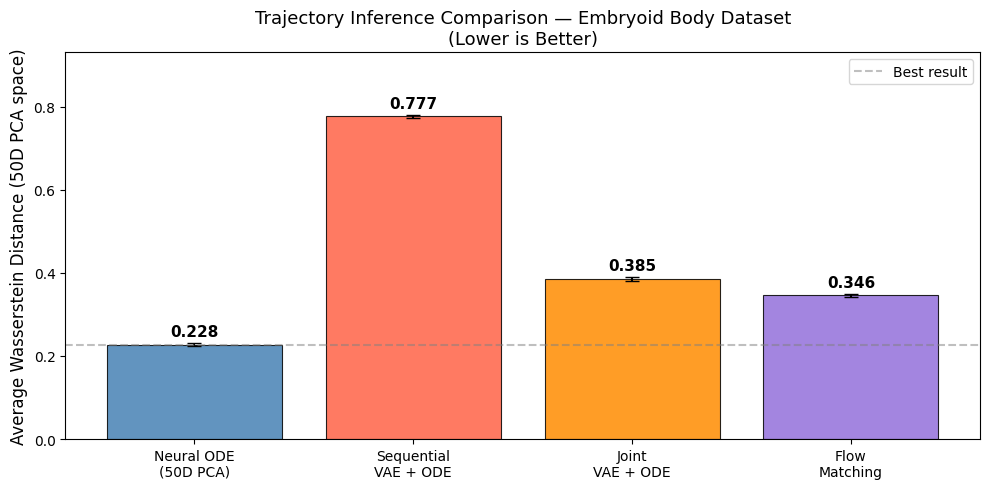


Final Results:
--------------------------------------------------
  Neural ODE (50D PCA)          : 0.2275 ± 0.0037
  Sequential VAE + ODE          : 0.7770 ± 0.0036
  Joint VAE + ODE               : 0.3854 ± 0.0044
  Flow Matching                 : 0.3457 ± 0.0036


In [8]:
methods = [
    'Neural ODE\n(50D PCA)',
    'Sequential\nVAE + ODE',
    'Joint\nVAE + ODE',
    'Flow\nMatching'
]
avgs = [avg_node, avg_vae, avg_joint, avg_fm]
stds = [std_node, std_vae, std_joint, std_fm]
colors = ['steelblue', 'tomato', 'darkorange', 'mediumpurple']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, avgs, yerr=stds, capsize=5,
              color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)

# annotate bars
for bar, avg, std in zip(bars, avgs, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
            f'{avg:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Average Wasserstein Distance (50D PCA space)', fontsize=12)
ax.set_title('Trajectory Inference Comparison — Embryoid Body Dataset\n'
             '(Lower is Better)', fontsize=13)
ax.set_ylim(0, max(avgs) + max(stds) + 0.15)
ax.axhline(y=min(avgs), color='gray', linestyle='--', alpha=0.5, label='Best result')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../figures/06_final_comparison.png', dpi=150)
plt.show()

print("\nFinal Results:")
print("-" * 50)
for m, a, s in zip(methods, avgs, stds):
    print(f"  {m.replace(chr(10), ' '):30s}: {a:.4f} ± {s:.4f}")

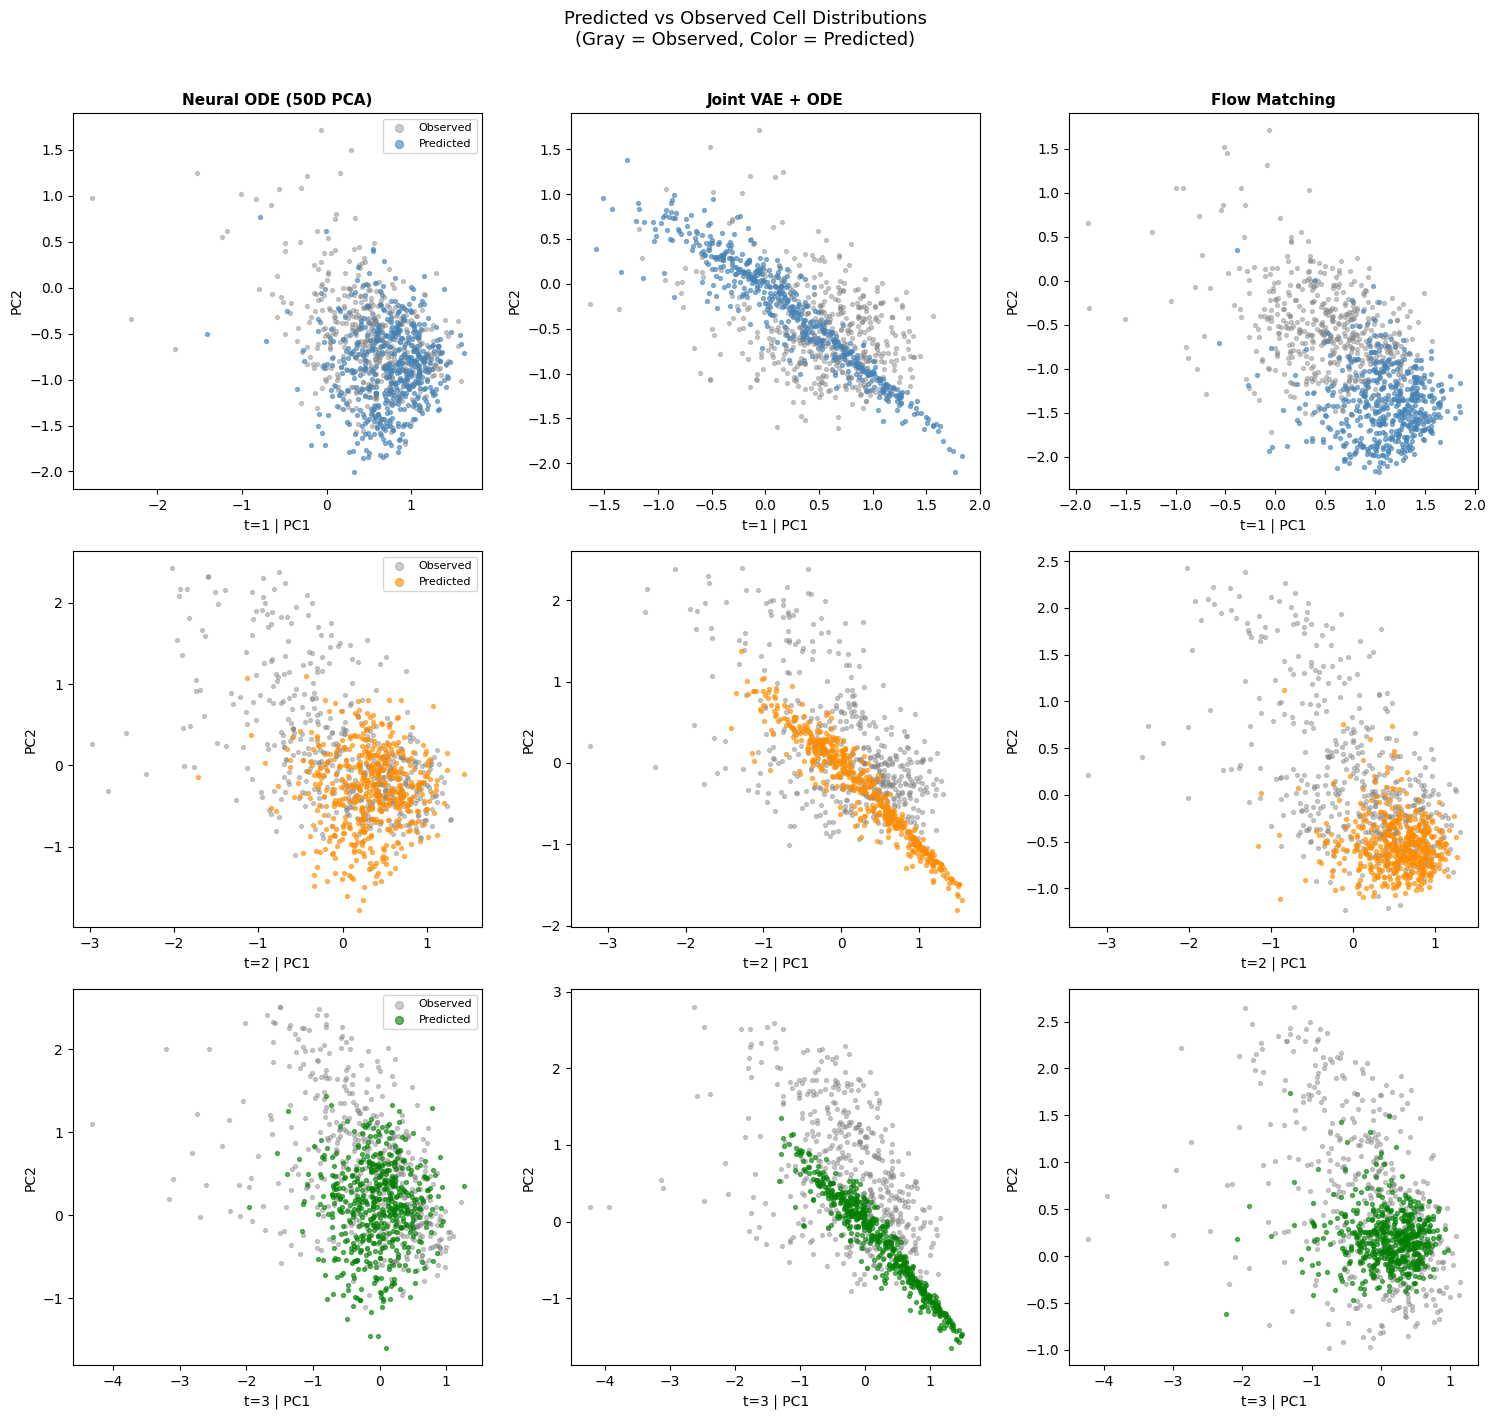

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 14))
method_names = ['Neural ODE (50D PCA)', 'Joint VAE + ODE', 'Flow Matching']
method_preds = [preds_node, preds_joint, preds_fm]
time_labels  = [1, 2, 3]
colors_t     = ['steelblue', 'darkorange', 'green']

for row, t in enumerate(time_labels):
    for col, (name, preds) in enumerate(zip(method_names, method_preds)):
        ax = axes[row, col]
        
        if t in preds:
            pred = preds[t]
        else:
            ax.set_visible(False)
            continue
        
        obs = obs_by_t_pca[t]
        idx_obs = np.random.choice(len(obs), size=min(500, len(pred)), replace=False)
        
        ax.scatter(obs[idx_obs, 0], obs[idx_obs, 1],
                  alpha=0.4, s=8, color='gray', label='Observed')
        ax.scatter(pred[:500, 0], pred[:500, 1],
                  alpha=0.6, s=8, color=colors_t[row], label='Predicted')
        
        if row == 0:
            ax.set_title(name, fontsize=11, fontweight='bold')
        ax.set_xlabel(f't={t} | PC1')
        ax.set_ylabel('PC2')
        if col == 0:
            ax.legend(markerscale=2, fontsize=8)

plt.suptitle('Predicted vs Observed Cell Distributions\n(Gray = Observed, Color = Predicted)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/06_predicted_vs_observed.png', dpi=150, bbox_inches='tight')
plt.show()

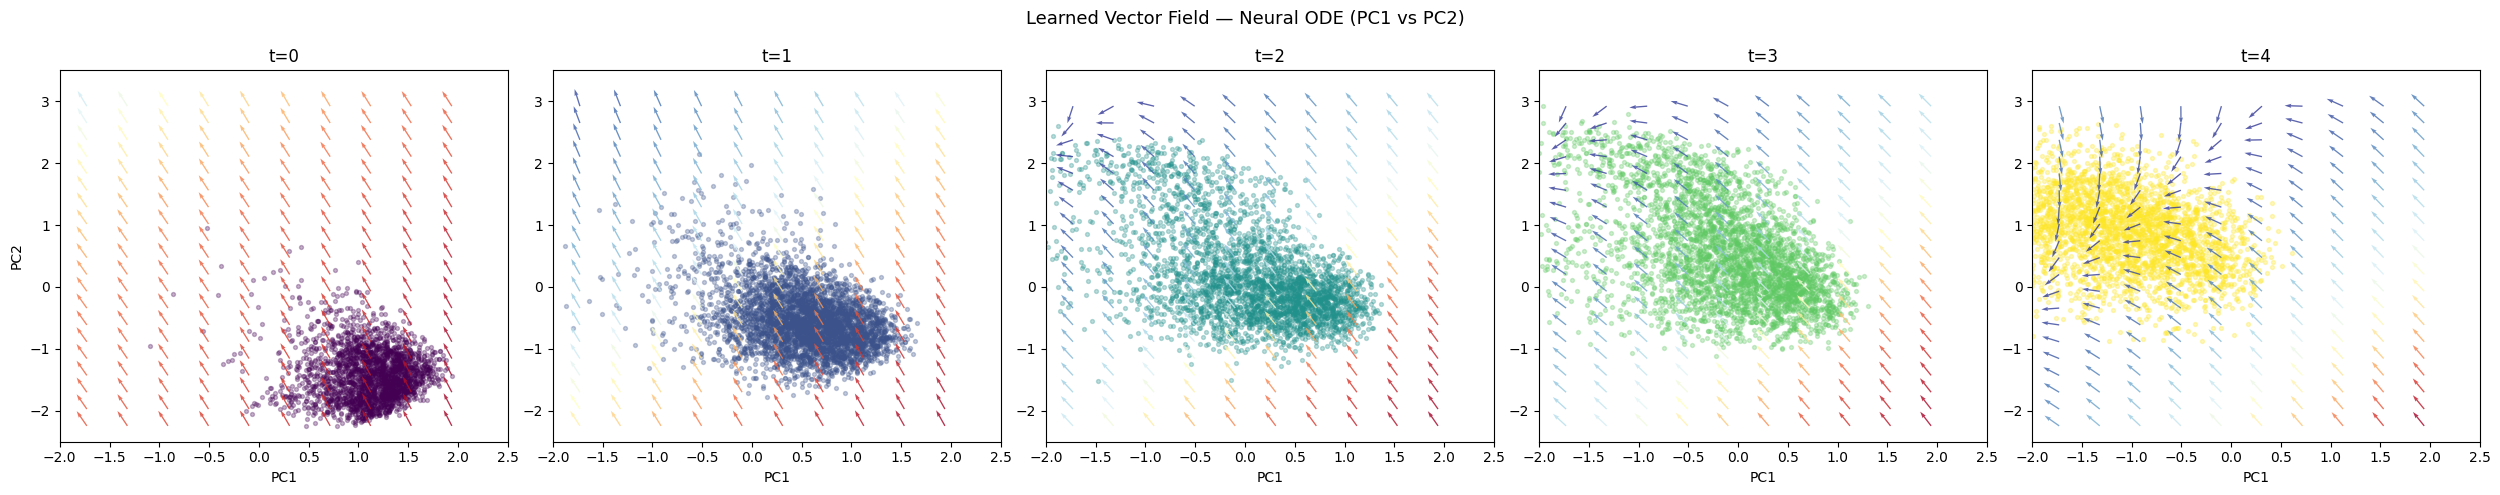

In [15]:
def plot_vector_field(model, data_scaled, labels, timepoints, scaler, title, filename):
    """
    Plot the learned vector field as arrows in PC1 vs PC2 space.
    Shows where the ODE pushes cells at each time point.
    """
    model.eval()
    
    # create a grid over PC1 x PC2 range
    x1_range = np.linspace(data_scaled[:, 0].min(), data_scaled[:, 0].max(), 20)
    x2_range = np.linspace(data_scaled[:, 1].min(), data_scaled[:, 1].max(), 20)
    xx, yy = np.meshgrid(x1_range, x2_range)
    
    fig, axes = plt.subplots(1, len(timepoints), figsize=(5*len(timepoints), 5))
    colors_t = plt.cm.viridis(np.linspace(0, 1, len(timepoints)))
    
    for idx, t in enumerate(timepoints):
        ax = axes[idx]
        
        # build grid points — set all dims beyond 2 to their mean at this timepoint
        mask = labels == t
        mean_state = data_scaled[mask].mean(axis=0)
        
        grid_points = np.tile(mean_state, (len(xx.ravel()), 1))
        grid_points[:, 0] = xx.ravel()
        grid_points[:, 1] = yy.ravel()
        
        grid_tensor = torch.FloatTensor(grid_points).to(device)
        t_tensor = torch.tensor(float(t)).to(device)
        
        with torch.no_grad():
            velocities = model(t_tensor, grid_tensor).cpu().numpy()
        
        u = velocities[:, 0].reshape(xx.shape)
        v = velocities[:, 1].reshape(yy.shape)
        
        # normalize arrow length for visibility
        speed = np.sqrt(u**2 + v**2) + 1e-8
        u_norm = u / speed
        v_norm = v / speed
        
        # plot observed cells
        obs_scaled = data_scaled[mask]
        ax.scatter(obs_scaled[:, 0], obs_scaled[:, 1],
                  c=[colors_t[idx]], alpha=0.3, s=8)
        
        # plot vector field arrows
        ax.quiver(xx, yy, u_norm, v_norm,
                 speed, cmap='RdYlBu_r',
                 alpha=0.8, scale=25, width=0.003)
        

        ax.set_xlim(-2, 2.5)
        ax.set_ylim(-2.5, 3.5)

        ax.set_title(f't={t}', fontsize=12)
        ax.set_xlabel('PC1')
        if idx == 0:
            ax.set_ylabel('PC2')
    
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(f'../figures/{filename}', dpi=150, bbox_inches='tight')
    plt.show()

plot_vector_field(
    model_node, data_scaled, labels, timepoints,
    scaler, 
    title='Learned Vector Field — Neural ODE (PC1 vs PC2)',
    filename='06_vector_field_node.png'
)

In [16]:
from sklearn.preprocessing import StandardScaler
from torchdiffeq import odeint

def mmd_loss(x, y, kernel_scales=[0.1, 0.5, 1.0, 2.0, 5.0]):
    def rbf_kernel(a, b, scale):
        dist = torch.cdist(a, b).pow(2)
        return torch.exp(-dist / (2 * scale ** 2))
    loss = 0.0
    for scale in kernel_scales:
        Kxx = rbf_kernel(x, x, scale).mean()
        Kyy = rbf_kernel(y, y, scale).mean()
        Kxy = rbf_kernel(x, y, scale).mean()
        loss += Kxx + Kyy - 2 * Kxy
    return loss / len(kernel_scales)

def train_and_evaluate_node(max_dim, epochs=200, n_samples=500, n_eval_runs=3):
    """Train Neural ODE at a given PCA dimensionality and return Wasserstein distance."""
    from TrajectoryNet import dataset
    
    # load data at this dimensionality
    eb = dataset.EBData("pcs", max_dim=max_dim)
    data_d = eb.data
    labels_d = eb.get_times()
    
    scaler_d = StandardScaler()
    data_d_scaled = scaler_d.fit_transform(data_d)
    
    data_by_t_d = {}
    for t in np.unique(labels_d):
        mask = labels_d == t
        data_by_t_d[t] = torch.FloatTensor(data_d_scaled[mask]).to(device)
    
    timepoints_d = np.unique(labels_d)
    
    # train Neural ODE
    model_d = ODEFunc(dim=max_dim).to(device)
    optimizer_d = torch.optim.Adam(model_d.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler_d = torch.optim.lr_scheduler.StepLR(optimizer_d, step_size=75, gamma=0.5)
    t_span = torch.FloatTensor(timepoints_d).to(device)
    
    for epoch in range(epochs):
        model_d.train()
        optimizer_d.zero_grad()
        
        idx0 = torch.randperm(data_by_t_d[0].shape[0])[:n_samples]
        z0 = data_by_t_d[0][idx0]
        z_pred = odeint(model_d, z0, t_span, method='euler')
        
        loss = 0.0
        energy = 0.0
        for i, t in enumerate(timepoints_d):
            z_pred_t = z_pred[i]
            idx_obs = torch.randperm(data_by_t_d[t].shape[0])[:n_samples]
            z_obs_t = data_by_t_d[t][idx_obs]
            loss += mmd_loss(z_pred_t, z_obs_t)
            t_tensor = torch.tensor(float(t)).to(device)
            vel = model_d(t_tensor, z_pred_t)
            energy += vel.pow(2).mean()
        
        total = loss + 0.1 * energy
        total.backward()
        torch.nn.utils.clip_grad_norm_(model_d.parameters(), 1.0)
        optimizer_d.step()
        scheduler_d.step()
    
    # evaluate in shared max_dim PCA space
    model_d.eval()
    all_avgs = []
    
    for _ in range(n_eval_runs):
        with torch.no_grad():
            idx = torch.randperm(data_by_t_d[0].shape[0])[:n_samples]
            z0 = data_by_t_d[0][idx]
            z_pred_eval = odeint(model_d, z0, t_span, method='dopri5')
        
        w_dists = []
        for t in timepoints_d[1:-1]:
            t_idx = list(timepoints_d).index(t)
            pred_scaled = z_pred_eval[t_idx].cpu().numpy()
            pred_pca = scaler_d.inverse_transform(pred_scaled)
            
            obs_mask = labels_d == t
            obs = data_d[obs_mask]
            idx_obs = np.random.choice(len(obs), size=n_samples, replace=False)
            obs_s = obs[idx_obs]
            
            w = np.mean([
                wasserstein_distance(pred_pca[:, d], obs_s[:, d])
                for d in range(max_dim)
            ])
            w_dists.append(w)
        all_avgs.append(np.mean(w_dists))
    
    return np.mean(all_avgs), np.std(all_avgs)

# run ablation across dimensionalities
dims_to_test = [5, 10, 20, 30, 50]
ablation_results = {}

print("Running dimensionality ablation...")
print("(This will take a few minutes)")
print("-" * 45)

for d in dims_to_test:
    print(f"  Training Neural ODE with max_dim={d}...")
    avg, std = train_and_evaluate_node(d, epochs=200, n_eval_runs=3)
    ablation_results[d] = (avg, std)
    print(f"  max_dim={d:2d}: Wasserstein = {avg:.4f} ± {std:.4f}")

print("\nAblation complete.")

Running dimensionality ablation...
(This will take a few minutes)
---------------------------------------------
  Training Neural ODE with max_dim=5...
  max_dim= 5: Wasserstein = 0.2366 ± 0.0044
  Training Neural ODE with max_dim=10...
  max_dim=10: Wasserstein = 0.3075 ± 0.0065
  Training Neural ODE with max_dim=20...
  max_dim=20: Wasserstein = 0.3065 ± 0.0050
  Training Neural ODE with max_dim=30...
  max_dim=30: Wasserstein = 0.2732 ± 0.0018
  Training Neural ODE with max_dim=50...
  max_dim=50: Wasserstein = 0.2352 ± 0.0015

Ablation complete.


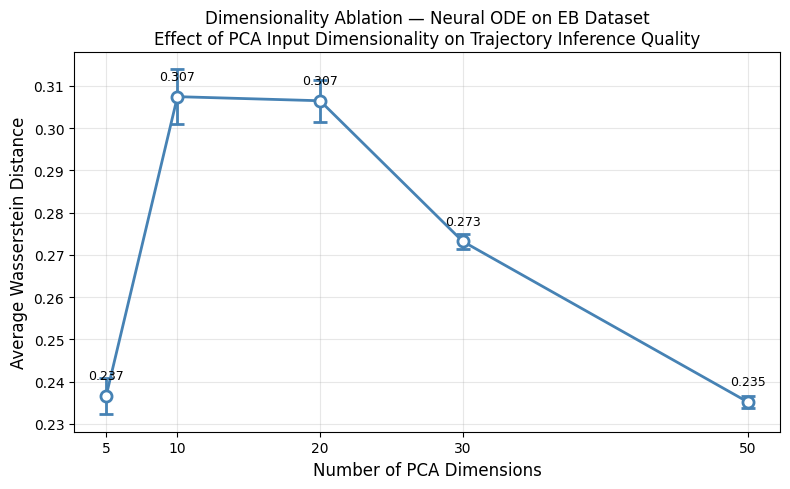


Ablation summary:
----------------------------------------
  max_dim= 5: 0.2366 ± 0.0044
  max_dim=10: 0.3075 ± 0.0065
  max_dim=20: 0.3065 ± 0.0050
  max_dim=30: 0.2732 ± 0.0018
  max_dim=50: 0.2352 ± 0.0015 <-- best


In [17]:
dims   = list(ablation_results.keys())
avgs   = [ablation_results[d][0] for d in dims]
stds   = [ablation_results[d][1] for d in dims]

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(dims, avgs, yerr=stds, marker='o', linewidth=2,
            markersize=8, capsize=5, color='steelblue', 
            markerfacecolor='white', markeredgewidth=2)

# annotate each point
for d, avg, std in zip(dims, avgs, stds):
    ax.annotate(f'{avg:.3f}', (d, avg),
                textcoords="offset points", xytext=(0, 12),
                ha='center', fontsize=9)

ax.set_xlabel('Number of PCA Dimensions', fontsize=12)
ax.set_ylabel('Average Wasserstein Distance', fontsize=12)
ax.set_title('Dimensionality Ablation — Neural ODE on EB Dataset\n'
             'Effect of PCA Input Dimensionality on Trajectory Inference Quality',
             fontsize=12)
ax.set_xticks(dims)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/06_dimensionality_ablation.png', dpi=150)
plt.show()

print("\nAblation summary:")
print("-" * 40)
best_dim = min(ablation_results, key=lambda d: ablation_results[d][0])
for d in dims:
    avg, std = ablation_results[d]
    marker = " <-- best" if d == best_dim else ""
    print(f"  max_dim={d:2d}: {avg:.4f} ± {std:.4f}{marker}")